In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [ ]:
import os
import pandas as pd
import numpy as np
import data.constants
import globals.constants
from data import plotting
import data.prepare.constants
from labeling import processing
import matplotlib.pyplot as plt

import importlib
importlib.reload(data.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

In [3]:
(train_x, train_y), val, normative_test, abnormal_test, (g_min, g_max) = processing.get_training_dataset(export_min_max=True)
print(f"Training dataset shape: {train_x.shape}, Validation dataset shape: {val.shape}, Test dataset shape: {normative_test.shape}, Abnormal test dataset shape: {abnormal_test.shape}")

Training dataset shape: (1296, 20, 1), Validation dataset shape: (162, 20, 1), Test dataset shape: (162, 20, 1), Abnormal test dataset shape: (181, 20, 1)


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1472 - val_loss: 0.0430
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0231 - val_loss: 0.0104
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0097 - val_loss: 0.0067
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 - val_loss: 0.0045
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038 - val_loss: 0.0030
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

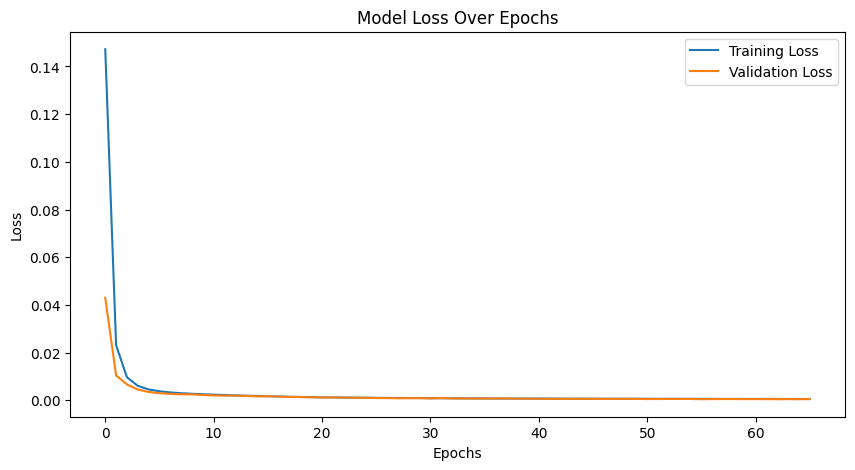

In [4]:
from labeling import autoencoder
from keras.callbacks import EarlyStopping, ModelCheckpoint

ae = autoencoder.build()

history = ae.fit(
    train_x, train_y,
    validation_data=(val, val),
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint('program/static/model.keras', monitor='val_loss', save_best_only=True)
    ]
)

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [5]:
sample_path = os.listdir(os.path.join(data.constants.parsed_data_dir, "capnostream"))[1]
sample: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.parsed_data_dir, "capnostream", sample_path))
print(sample.attrs)
signal = sample["co2_wave"].to_numpy()
units = processing.signal_to_units(signal, g_min, g_max)

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}


In [7]:
threshold = autoencoder.calculate_threshold(ae, val, percentile=96, export=True)
print(f"Calculated threshold: {threshold}")
predict = autoencoder.predictor(ae, threshold)
batch_predict = autoencoder.batch_predictor(ae, threshold)

Calculated threshold: 0.001430183254159612


In [8]:
# statistics!
from itertools import compress
from time import perf_counter

# mean validation reconstruction error
val_reconstructions = ae.predict(val, verbose='silent')
mean_val_recon_error = np.mean(np.mean(np.power(val - val_reconstructions, 2), axis=1))
print(f"Mean reconstruction error on validation set: {mean_val_recon_error}")

# normative unit accuracy and mean reconstruction error
normative_recons, normative_errors, normative_labels = batch_predict(normative_test.reshape(-1, data.prepare.constants.unit_length))
normative_accuracy = round(np.sum(normative_labels) / len(normative_labels), 2)
mean_normative_recon_error = np.mean(normative_errors)
print(f"Normative unit accuracy: {normative_accuracy * 100}%, Mean reconstruction error: {mean_normative_recon_error}")

# abnormal unit accuracy and mean reconstruction error
abnormal_recons, abnormal_errors, abnormal_labels = batch_predict(abnormal_test.reshape(-1, data.prepare.constants.unit_length) )
abnormal_accuracy = round(np.sum(~abnormal_labels) / len(abnormal_labels), 2)
mean_abnormal_recon_error = np.mean(abnormal_errors)
print(f"Abnormal unit accuracy: {abnormal_accuracy * 100}%, Mean reconstruction error: {mean_abnormal_recon_error}")


start = perf_counter()
recons, errors, labels = batch_predict(units)
elapsed = perf_counter() - start

print(f"Classification of {len(units)} took {elapsed:.4f} s ({len(units)/elapsed:.2f} units/s)")
# predictions: list[tuple[np.ndarray, np.ndarray, np.floating, np.bool]] = list(zip(units, recons, errors, labels))
# valid_predictions = list(compress(predictions, labels))
# invalid_predictions = list(compress(predictions, ~labels))

# print(f"Total units: {len(predictions)}")
# print(f"Valid units: {len(valid_predictions)} ({round(len(valid_predictions) / len(predictions) * 100, 2)}%)")
# print(f"Invalid units: {len(invalid_predictions)} ({round(len(invalid_predictions) / len(predictions) * 100, 2)}%)")


Mean reconstruction error on validation set: 0.0004751276027684736
Normative unit accuracy: 88.0%, Mean reconstruction error: 0.0006864812719206759
Abnormal unit accuracy: 100.0%, Mean reconstruction error: 0.05184532092390288
Classification of 40386 took 0.6721 s (60090.67 units/s)


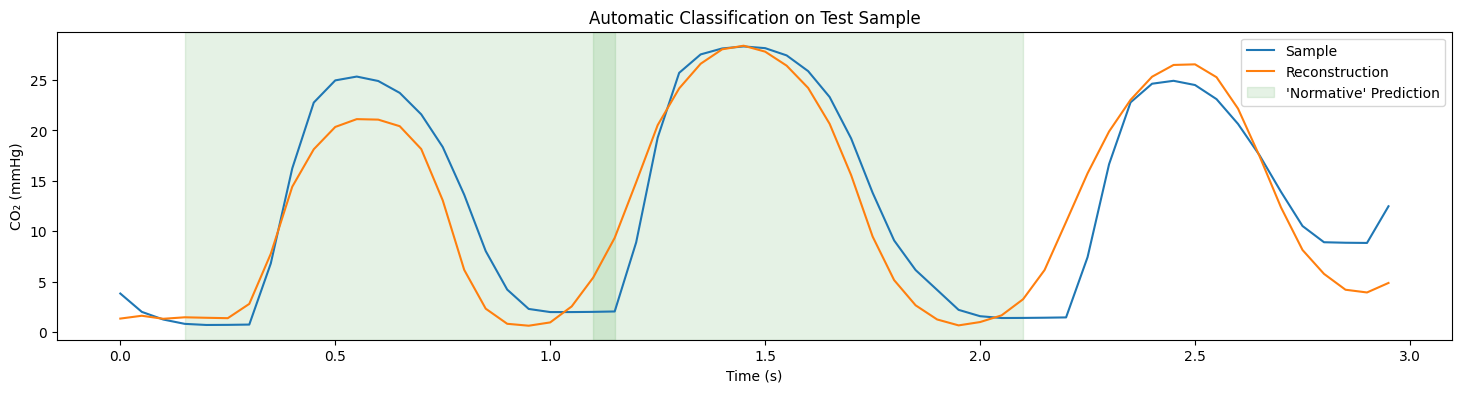

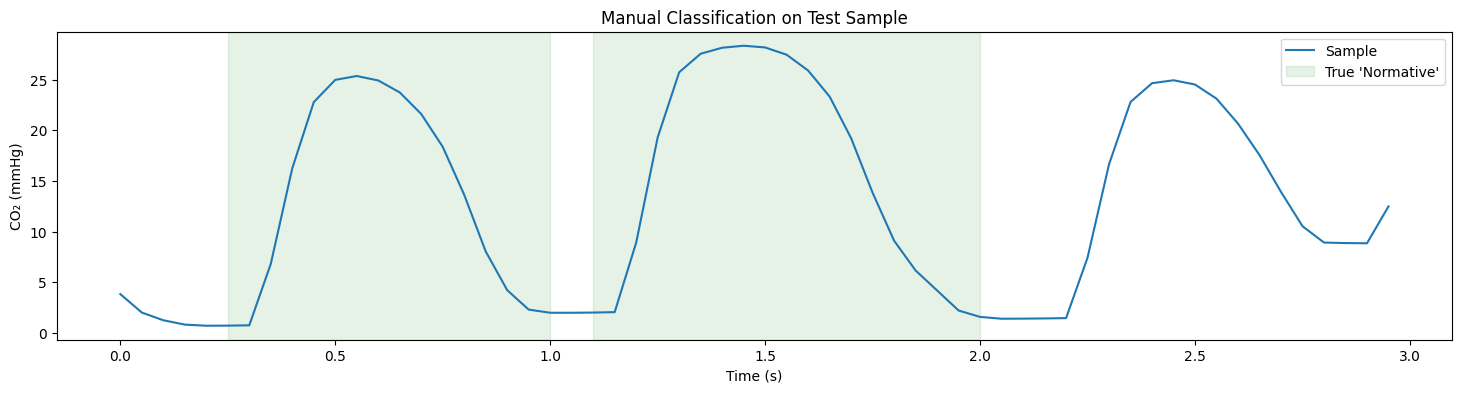

In [9]:
from numpy.lib.stride_tricks import sliding_window_view

test_sample_start_index = 1500
test_sample_length = data.prepare.constants.unit_length * 3 # 3 units = 3 seconds
test_sample = signal[test_sample_start_index:test_sample_start_index + test_sample_length]
test_units = sliding_window_view(test_sample, (data.prepare.constants.unit_length, ))

test_recons, test_errors, test_labels = batch_predict(test_units)

test_sample_scaled = processing.reverse_sample_scaling(test_sample, g_min, g_max)
test_recons_scaled_stacked = processing.reverse_sample_scaling(processing.stack_signals(test_recons), g_min, g_max)
test_sample_time = np.arange(0, len(test_sample)) / globals.constants.capnostream_sr

plt.figure(figsize=(18, 4))
plt.plot(test_sample_time, test_sample_scaled, label='Sample')
plt.plot(test_sample_time, test_recons_scaled_stacked, label='Reconstruction')
plt.xlabel("Time (s)")
plt.ylabel("CO₂ (mmHg)")

valid_prediction_distance = 0
for i in range(len(test_units)):
    original = test_units[i]
    recon = test_recons[i]
    error = test_errors[i]
    label = test_labels[i]

    if label: 
        if valid_prediction_distance == 0:
            plt.axvspan(i / globals.constants.capnostream_sr, (i + data.prepare.constants.unit_length) / globals.constants.capnostream_sr, color='green', alpha=0.1, label="'Normative' Prediction" if "'Normative' Prediction" not in plt.gca().get_legend_handles_labels()[1] else "")
            valid_prediction_distance = 3 # reset distance counter
    else:
        valid_prediction_distance = max(0, valid_prediction_distance - 1)

plt.title("Automatic Classification on Test Sample")
plt.legend()
plt.savefig("automatic_classification_test_sample.png", dpi=300)
plt.show()

true_test_sample_labels = [
    (5, 20),
    (22, 40)
]

plt.figure(figsize=(18, 4))
plt.plot(test_sample_time, test_sample_scaled, label='Sample')
plt.xlabel("Time (s)")
plt.ylabel("CO₂ (mmHg)")

for (start, end) in true_test_sample_labels:
    plt.axvspan(start / globals.constants.capnostream_sr, end / globals.constants.capnostream_sr, color='green', alpha=0.1, label="True 'Normative'" if "True 'Normative'" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("Manual Classification on Test Sample")
plt.legend()
plt.savefig("manual_classification_test_sample.png", dpi=300)
plt.show()
